In [8]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path('muon_tag_conv_prompt')
PLOT_DIR.mkdir(exist_ok=True)


In [9]:
H5_FILE = '/data/user/tvaneede/muon_tagging/data_processing/output/h5/merged.h5'

with h5py.File(H5_FILE, 'r') as f:
    reco_etot   = f['RecoETot']['value'][:]   # GeV
    reco_zenith = f['RecoZenith']['value'][:]  # radians

print(f'Total events: {len(reco_etot)}')
print(f'Energy range: {reco_etot.min():.0f} – {reco_etot.max():.0f} GeV')


Total events: 30
Energy range: 14902 – 209547 GeV


In [10]:
LIVETIME = 411785301.60  # seconds

V8_PATH = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/combined'
    '/IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight_PassingHESE_ExtraMuon'
    '/dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight_PassingHESE_ExtraMuon.parquet'
)

df = pd.read_parquet(V8_PATH)
df_muon = df[~np.isnan(df['MuonWeight'])].copy()

sim_energy         = df_muon['reco_energy'].values                              # GeV
sim_weights_conv   = df_muon['MuonWeightCombinedConv'].values   * LIVETIME
sim_weights_prompt = df_muon['MuonWeightCombinedPrompt'].values * LIVETIME
sim_weights_comb   = sim_weights_conv + sim_weights_prompt

print(f'Simulation events (muon): {len(sim_energy)}')
print(f'Conv   weighted sum: {sim_weights_conv.sum():.3f}')
print(f'Prompt weighted sum: {sim_weights_prompt.sum():.3f}')
print(f'Combined weighted sum: {sim_weights_comb.sum():.3f}')


Simulation events (muon): 191
Conv   weighted sum: 6.599
Prompt weighted sum: 26.854
Combined weighted sum: 33.453


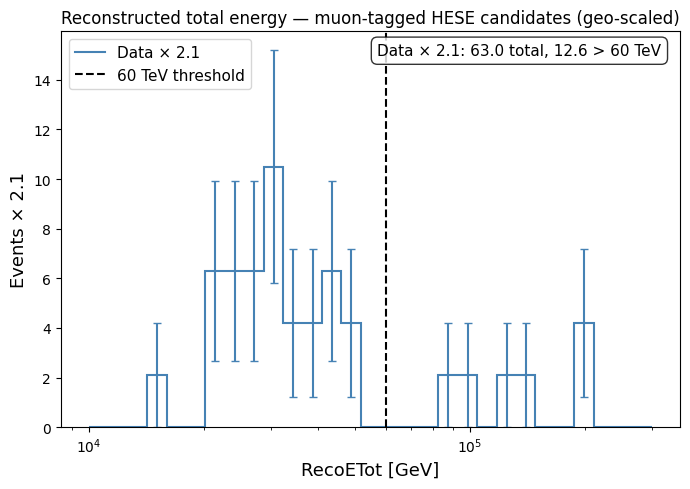

In [11]:
E_THRESHOLD = 60e3  # GeV (60 TeV)
GEO_FACTOR  = 2.1   # geometric acceptance correction

n_total = len(reco_etot)
n_above  = np.sum(reco_etot > E_THRESHOLD)

bins        = np.logspace(np.log10(10e3), np.log10(300e3), 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

n_raw   = np.histogram(reco_etot, bins=bins)[0]
n_geo   = n_raw * GEO_FACTOR
err_geo = np.sqrt(n_raw) * GEO_FACTOR

fig, ax = plt.subplots(figsize=(7, 5))
ax.stairs(n_geo, bins, color='steelblue', linewidth=1.5, label=f'Data × {GEO_FACTOR}')
mask = n_geo > 0
ax.errorbar(bin_centers[mask], n_geo[mask], yerr=err_geo[mask],
            fmt='none', color='steelblue', capsize=3)
ax.axvline(E_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label='60 TeV threshold')
ax.set_xscale('log')
ax.set_xlabel('RecoETot [GeV]', fontsize=13)
ax.set_ylabel(f'Events × {GEO_FACTOR}', fontsize=13)
ax.set_title('Reconstructed total energy — muon-tagged HESE candidates (geo-scaled)', fontsize=12)
textstr = f'Data × {GEO_FACTOR}: {n_total * GEO_FACTOR:.1f} total, {n_above * GEO_FACTOR:.1f} > 60 TeV'
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=11, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'reco_etot_data_geo.pdf', bbox_inches='tight')
plt.show()


In [12]:
# Error calculation:
#   frac_geo = (n_obs * GEO_FACTOR) / W,  sigma = frac_geo * sqrt(1/n_obs + (sigma_sim/W)^2)
#   sigma_sim = sqrt(sum(w_i^2)),  sigma_data_geo = sqrt(n_obs) * GEO_FACTOR

def data_over_sim(n_data, w):
    W              = w.sum()
    sigma_sim      = np.sqrt((w**2).sum())
    frac_geo       = n_data * GEO_FACTOR / W
    sigma_data_geo = np.sqrt(n_data) * GEO_FACTOR
    sigma_frac_geo = frac_geo * np.sqrt(1.0/n_data + (sigma_sim/W)**2)
    return frac_geo, sigma_frac_geo, n_data, sigma_data_geo, W, sigma_sim

above = sim_energy > E_THRESHOLD

# Weighted sums
print(f"{'':30s}  {'All events':>15}  {'> 60 TeV':>15}")
for label, w in [('Conv', sim_weights_conv), ('Prompt', sim_weights_prompt), ('Combined', sim_weights_comb)]:
    print(f"  {label:28s}  {w.sum():15.3f}  {w[above].sum():15.3f}")
print()

# Conv only
frac_conv_all,   err_conv_all,   *_ = data_over_sim(n_total, sim_weights_conv)
frac_conv_above, err_conv_above, *_ = data_over_sim(n_above, sim_weights_conv[above])

# Conv + Prompt combined
frac_comb_all,   err_comb_all,   *_ = data_over_sim(n_total, sim_weights_comb)
frac_comb_above, err_comb_above, *_ = data_over_sim(n_above, sim_weights_comb[above])

print(f"Scaling factors (data×{GEO_FACTOR} / simulation):")
print(f"{'':30s}  {'All events':>20}  {'> 60 TeV':>20}")
print(f"{'Conv only':30s}  {frac_conv_all:7.2f} ± {err_conv_all:.2f}      {frac_conv_above:7.2f} ± {err_conv_above:.2f}")
print(f"{'Conv + Prompt':30s}  {frac_comb_all:7.2f} ± {err_comb_all:.2f}      {frac_comb_above:7.2f} ± {err_comb_above:.2f}")


                                     All events         > 60 TeV
  Conv                                    6.599            0.652
  Prompt                                 26.854            5.997
  Combined                               33.453            6.649

Scaling factors (data×2.1 / simulation):
                                          All events              > 60 TeV
Conv only                          9.55 ± 2.30        19.31 ± 8.83
Conv + Prompt                      1.88 ± 0.39         1.89 ± 0.82


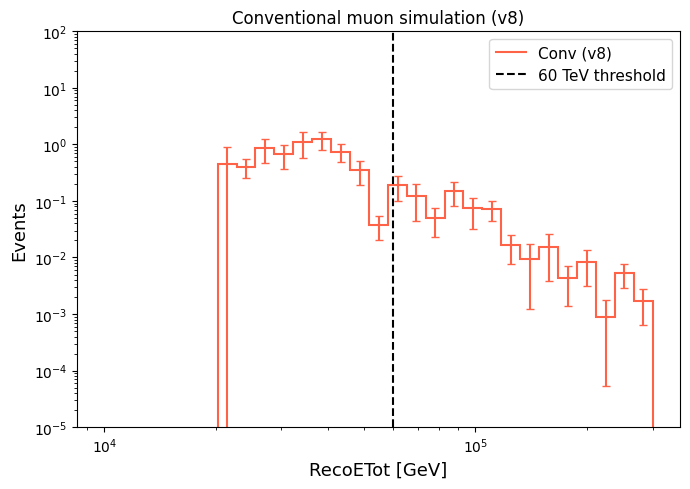

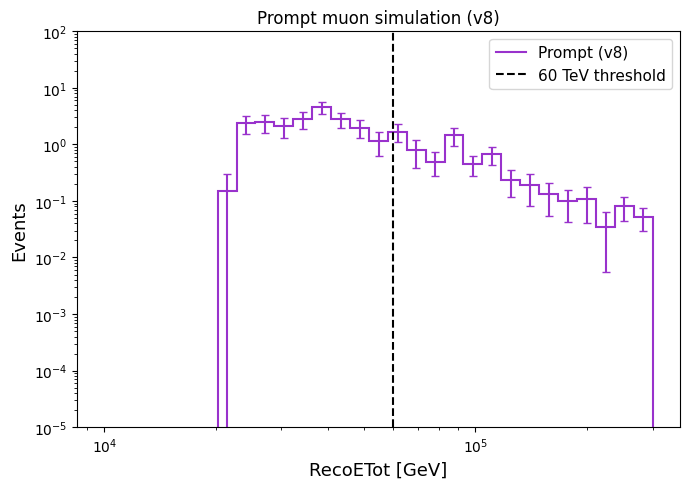

In [13]:
def plot_sim_only(sim_energy, sim_weights, label, color, title, fname):
    fig, ax = plt.subplots(figsize=(7, 5))
    w_sum = np.histogram(sim_energy, bins=bins, weights=sim_weights)[0]
    err_s = np.sqrt(np.histogram(sim_energy, bins=bins, weights=sim_weights**2)[0])
    ax.stairs(w_sum, bins, color=color, linewidth=1.5, label=label)
    mask = w_sum > 0
    ax.errorbar(bin_centers[mask], w_sum[mask], yerr=err_s[mask],
                fmt='none', color=color, capsize=3)
    ax.axvline(E_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label='60 TeV threshold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-5, 1e2)
    ax.set_xlabel('RecoETot [GeV]', fontsize=13)
    ax.set_ylabel('Events', fontsize=13)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, bbox_inches='tight')
    plt.show()

plot_sim_only(sim_energy, sim_weights_conv,
              label='Conv (v8)', color='tomato',
              title='Conventional muon simulation (v8)',
              fname='reco_etot_sim_conv.pdf')

plot_sim_only(sim_energy, sim_weights_prompt,
              label='Prompt (v8)', color='darkorchid',
              title='Prompt muon simulation (v8)',
              fname='reco_etot_sim_prompt.pdf')


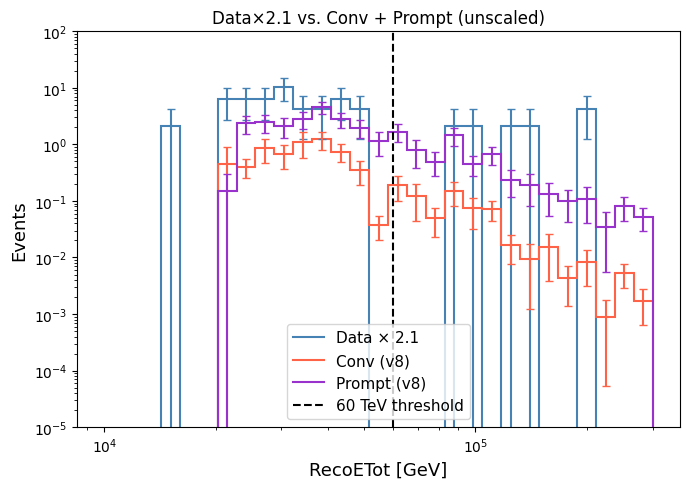

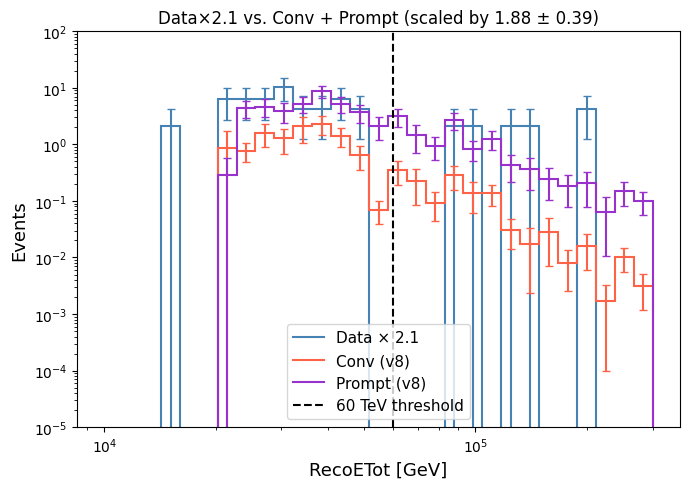

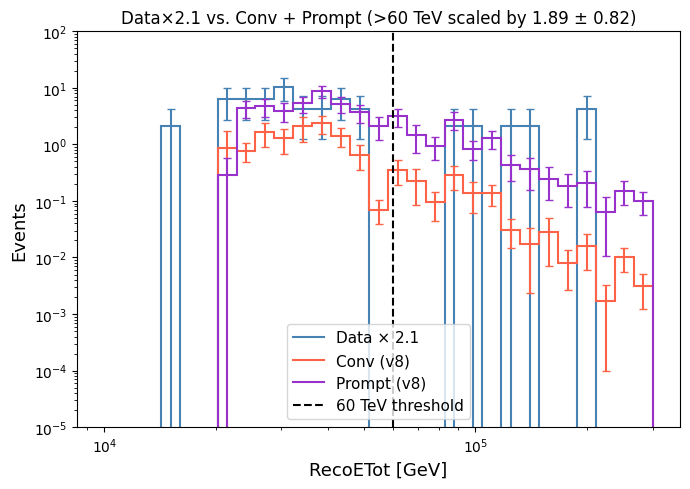

In [14]:
def plot_data_conv_prompt(sim_energy, w_conv, w_prompt, bins, title, fname):
    fig, ax = plt.subplots(figsize=(7, 5))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Data
    n_raw   = np.histogram(reco_etot, bins=bins)[0]
    n_geo   = n_raw * GEO_FACTOR
    err_geo = np.sqrt(n_raw) * GEO_FACTOR
    ax.stairs(n_geo, bins, color='steelblue', linewidth=1.5, label=f'Data × {GEO_FACTOR}')
    mask_d = n_geo > 0
    ax.errorbar(bin_centers[mask_d], n_geo[mask_d], yerr=err_geo[mask_d],
                fmt='none', color='steelblue', capsize=3)

    # Conv
    wc = np.histogram(sim_energy, bins=bins, weights=w_conv)[0]
    ec = np.sqrt(np.histogram(sim_energy, bins=bins, weights=w_conv**2)[0])
    ax.stairs(wc, bins, color='tomato', linewidth=1.5, label='Conv (v8)')
    mask_c = wc > 0
    ax.errorbar(bin_centers[mask_c], wc[mask_c], yerr=ec[mask_c],
                fmt='none', color='tomato', capsize=3)

    # Prompt
    wp = np.histogram(sim_energy, bins=bins, weights=w_prompt)[0]
    ep = np.sqrt(np.histogram(sim_energy, bins=bins, weights=w_prompt**2)[0])
    ax.stairs(wp, bins, color='darkorchid', linewidth=1.5, label='Prompt (v8)')
    mask_p = wp > 0
    ax.errorbar(bin_centers[mask_p], wp[mask_p], yerr=ep[mask_p],
                fmt='none', color='darkorchid', capsize=3)

    ax.axvline(E_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label='60 TeV threshold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-5, 1e2)
    ax.set_xlabel('RecoETot [GeV]', fontsize=13)
    ax.set_ylabel('Events', fontsize=13)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, bbox_inches='tight')
    plt.show()


# Unscaled
plot_data_conv_prompt(sim_energy, sim_weights_conv, sim_weights_prompt, bins,
                      title=f'Data×{GEO_FACTOR} vs. Conv + Prompt (unscaled)',
                      fname='reco_etot_data_conv_prompt_unscaled.pdf')

# Scaled by combined fraction (all events)
plot_data_conv_prompt(sim_energy, sim_weights_conv * frac_comb_all, sim_weights_prompt * frac_comb_all, bins,
                      title=f'Data×{GEO_FACTOR} vs. Conv + Prompt (scaled by {frac_comb_all:.2f} ± {err_comb_all:.2f})',
                      fname='reco_etot_data_conv_prompt_scaled_all.pdf')

# Scaled by combined fraction (>60 TeV)
plot_data_conv_prompt(sim_energy, sim_weights_conv * frac_comb_above, sim_weights_prompt * frac_comb_above, bins,
                      title=f'Data×{GEO_FACTOR} vs. Conv + Prompt (>60 TeV scaled by {frac_comb_above:.2f} ± {err_comb_above:.2f})',
                      fname='reco_etot_data_conv_prompt_scaled_above60tev.pdf')
